In [15]:
import pandas as pd
import matplotlib.pyplot as plt

housing = pd.read_csv("../data/cleaned/housing_master_updated.csv")

In [16]:
housing.head()

,country_code,country,year,nominal_house_price_index,real_house_price_index,rent_price_index,price_to_income_ratio,price_to_rent_ratio,nominal_price_yoy_growth_pct,real_price_yoy_growth_pct,...,rent_total_growth_pct,average_annual_wage,household_disposable_income,interest_rate,population,housing_pressure,true_affordability,financing_pressure,population_growth,demand_pressure
0,AUT,Austria,2010,77.3225,85.976098,82.808831,82.870314,93.368295,NaN,NaN,...,0.000000,36382.634,25697.230613,3.226383,8357367.0,0.002125,332.338331,249.472025,NaN,NaN
1,AUT,Austria,2011,81.4725,87.855382,85.556472,86.435537,95.219128,5.367131,2.185821,...,3.318053,37127.955,26186.947975,3.319658,8384901.0,0.002194,321.420700,270.460864,0.329458,-5.037673
2,AUT,Austria,2012,86.8625,91.544150,89.325850,88.277640,97.242014,6.615729,4.198682,...,7.869956,38215.019,27163.483183,2.371175,8420328.0,0.002273,312.718183,205.966188,0.422509,-6.193220
3,AUT,Austria,2013,91.1950,94.204279,92.101098,93.843900,99.016565,4.987768,2.905843,...,11.221348,39035.153,27214.780864,2.010758,8472176.0,0.002336,298.424046,183.371106,0.615748,-4.372020
4,AUT,Austria,2014,94.6750,95.971274,95.760014,95.740826,98.867577,3.815999,1.875705,...,15.639857,39974.325,27687.507113,1.487292,8538350.0,0.002368,292.447923,140.809339,0.781074,-3.034924


In [17]:
housing.shape

(139, 22)

In [18]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country_code                    139 non-null    str    
 1   country                         139 non-null    str    
 2   year                            139 non-null    int64  
 3   nominal_house_price_index       139 non-null    float64
 4   real_house_price_index          139 non-null    float64
 5   rent_price_index                139 non-null    float64
 6   price_to_income_ratio           139 non-null    float64
 7   price_to_rent_ratio             139 non-null    float64
 8   nominal_price_yoy_growth_pct    130 non-null    float64
 9   real_price_yoy_growth_pct       130 non-null    float64
 10  rent_yoy_growth_pct             130 non-null    float64
 11  nominal_price_total_growth_pct  139 non-null    float64
 12  rent_total_growth_pct           139 non-null   

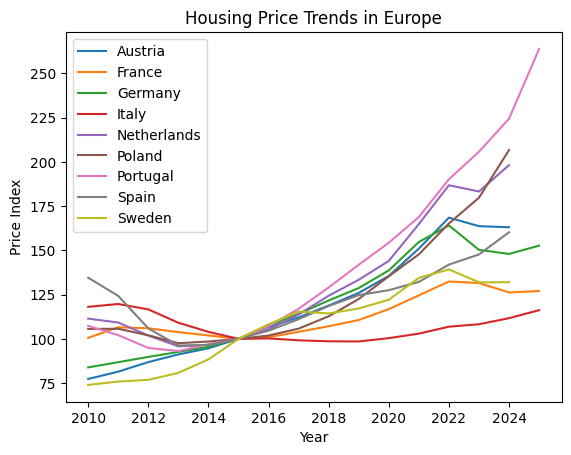

In [19]:
for country in housing["country"].unique():
    subset = housing[housing["country"] == country]
    plt.plot(subset["year"], subset["nominal_house_price_index"], label=country)

plt.legend()
plt.title("Housing Price Trends in Europe")
plt.xlabel("Year")
plt.ylabel("Price Index")
plt.show()

In [22]:
#latest available rent growth for each country (from year to year)
rent_latest = (
    housing
    .sort_values("year")
    .groupby("country")
    .tail(1)
)

# Sort for better visualization
rent_latest = rent_latest.sort_values("rent_total_growth_pct", ascending=False)

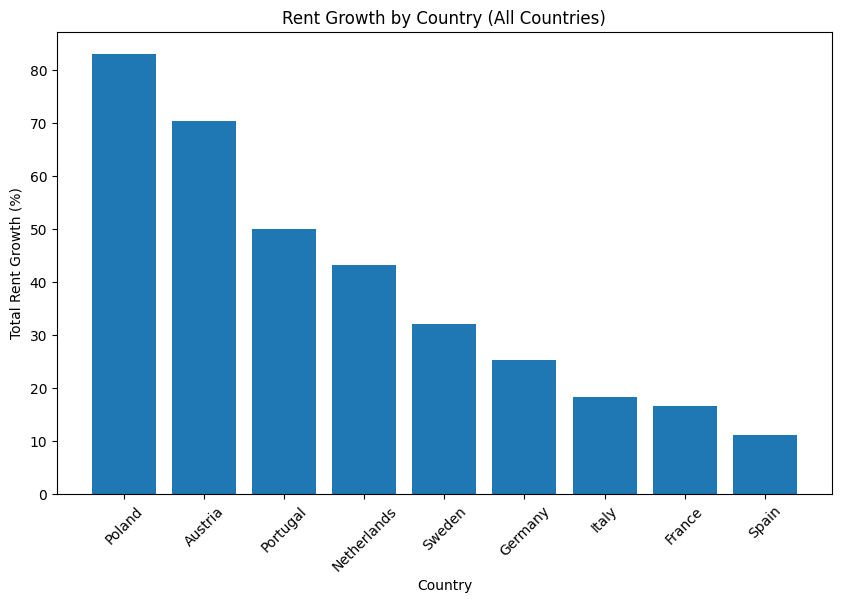

In [23]:
# Plot
plt.figure(figsize=(10,6))
plt.bar(rent_latest["country"], rent_latest["rent_total_growth_pct"])

plt.xticks(rotation=45)
plt.title("Rent Growth by Country (All Countries)")
plt.xlabel("Country")
plt.ylabel("Total Rent Growth (%)")

plt.show()

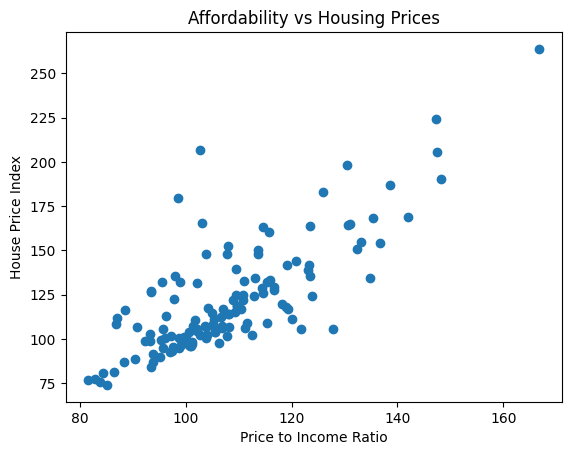

In [ ]:
plt.scatter(housing["price_to_income_ratio"], housing["nominal_house_price_index"])

plt.xlabel("Price to Income Ratio")
plt.ylabel("House Price Index")
plt.title("Affordability vs Housing Prices")
plt.show()

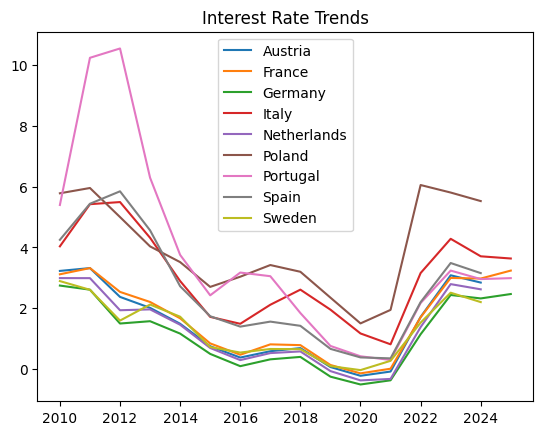

In [ ]:
for country in housing["country"].unique():
    subset = housing[housing["country"] == country]
    plt.plot(subset["year"], subset["interest_rate"], label=country)

plt.legend()
plt.title("Interest Rate Trends")
plt.show()

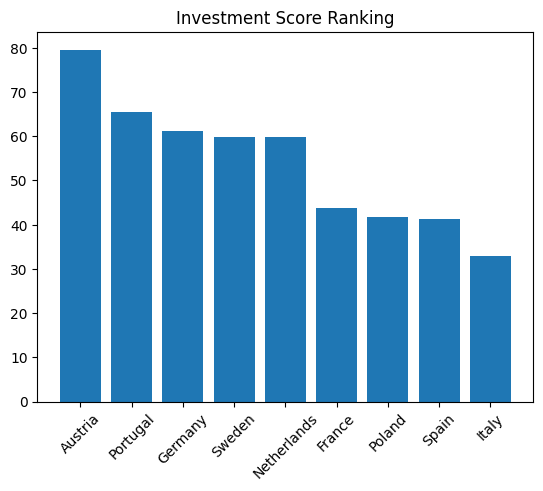

In [ ]:
ranking = pd.read_csv("../data/cleaned/investment_ranking_with_extra_indicators.csv")

plt.bar(ranking["country"], ranking["investment_score"])
plt.xticks(rotation=45)
plt.title("Investment Score Ranking")
plt.show()

1. Austria shows the strongest overall investment score driven by stable growth and affordability.
2. Portugal shows strong growth but moderate affordability pressure.
3. Germany remains a balanced and stable investment market.
4. Southern European countries like Spain and Italy show lower attractiveness due to weaker growth and affordability challenges.
5. Interest rate increases reduce attractiveness across most countries.